<a href="https://colab.research.google.com/github/jahnavikrishna037-collab/ML-project/blob/main/model2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
!pip install xgboost


# Importing Libraries

In [12]:
import pandas as pd
import numpy as np

# Model Selection
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Model
from xgboost import XGBClassifier


# Loading Dataset and Checking Missing Values

In [13]:
import pandas as pd

from google.colab import files
uploaded = files.upload()
df = pd.read_csv("pregnancy_clinical_simulation_dataset.csv")
print("Dataset Shape:", df.shape)
df.head()
df.isnull().sum()


Saving pregnancy_clinical_simulation_dataset.csv to pregnancy_clinical_simulation_dataset (1).csv
Dataset Shape: (2000, 39)


,0
Age,100
Height_cm,100
Weight_kg,100
BMI,100
SocioeconomicStatus,100
RuralUrban,100
Gravida,100
Para,100
PreviousMiscarriages,100
PreviousStillbirth,100


# Create Target Variable
Normal

Abortion

Miscarriage

Stillbirth

In [14]:
import random

def assign_outcome_probabilistic(row):

    # Base probability (normal pregnancy baseline risk)
    prob = 0.05

    # Increase risk based on conditions
    if row["GrowthStatus"] == "Growth Restricted":
        prob += 0.20

    if row["ChronicHypertension"] == 1:
        prob += 0.15

    if row["ChronicDiabetes"] == 1:
        prob += 0.15

    if row["PreviousMiscarriages"] > 0:
        prob += 0.20

    if row["Age"] > 35:
        prob += 0.10

    if row["Smoking"] == 1:
        prob += 0.10

    if row["Hemoglobin"] < 10:
        prob += 0.10

    # Cap probability
    prob = min(prob, 0.85)

    # Random outcome based on probability
    rand_val = random.random()

    if rand_val < prob:
        # If risky, classify type of complication
        if prob > 0.6:
            return "Stillbirth"
        elif prob > 0.4:
            return "Miscarriage"
        else:
            return "Abortion"
    else:
        return "Normal"

df["Outcome"] = df.apply(assign_outcome_probabilistic, axis=1)

df["Outcome"].value_counts()


,count
Outcome,
Normal,1533
Abortion,357
Miscarriage,88
Stillbirth,22


# Feature Engineering
## Metabolic Risk Score

In [15]:
df["MetabolicRiskScore"] = (
    df["BMI"] +
    df["FastingBloodSugar"] +
    df["HbA1c"]
)


## Blood Pressure Ratio


In [16]:
df["BP_Ratio"] = df["SystolicBP"] / df["DiastolicBP"]


## High Risk Age Flag

In [17]:
df["HighRiskAge"] = df["Age"].apply(lambda x: 1 if x > 35 else 0)


# Separating Features & Target

In [18]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# Encode target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Classes:", le.classes_)


Classes: ['Abortion' 'Miscarriage' 'Normal' 'Stillbirth']


# Identifying Column Types

In [19]:
categorical_cols = X.select_dtypes(include=["object"]).columns
numeric_cols = X.select_dtypes(exclude=["object"]).columns

print("Categorical Columns:", list(categorical_cols))
print("Numeric Columns:", list(numeric_cols))


Categorical Columns: ['SocioeconomicStatus', 'PlacentalPosition', 'GrowthStatus']
Numeric Columns: ['Age', 'Height_cm', 'Weight_kg', 'BMI', 'RuralUrban', 'Gravida', 'Para', 'PreviousMiscarriages', 'PreviousStillbirth', 'PreviousPretermBirth', 'PreviousCSection', 'InterPregnancyInterval_Months', 'SystolicBP', 'DiastolicBP', 'MeanArterialPressure', 'HeartRate', 'BodyTemperature_C', 'FastingBloodSugar', 'HbA1c', 'Hemoglobin', 'TSH', 'CRP', 'Smoking', 'Alcohol', 'DrugUse', 'ChronicHypertension', 'ChronicDiabetes', 'ThyroidDisorder', 'PCOS', 'GestationalAge_Weeks', 'FetalHeartRate', 'AmnioticFluidIndex', 'USG_BPD_mm', 'USG_FL_mm', 'USG_AC_mm', 'DopplerResistanceIndex', 'MetabolicRiskScore', 'BP_Ratio', 'HighRiskAge']


# Creating Preprocessing Pipeline

In [20]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)


# Train Test Split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)


# Building XGBoost Model

In [22]:
model = XGBClassifier(
    n_estimators=150,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=1,        # L1 regularization
    reg_lambda=2,       # L2 regularization
    objective="multi:softprob",
    num_class=4,
    eval_metric="mlogloss",
    random_state=42
)


# Creating Full Pipeline

In [23]:
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", model)
])


# Train Model

In [24]:
pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Age', 'Height_cm', 'Weight_kg', 'BMI', 'RuralUrban', 'Gravida', 'Para',
       'PreviousMiscarriages', 'PreviousStillbirth', 'PreviousPretermBirth',
       'PreviousCSection', 'InterPregnancyInterval_Month...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=3, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=150, n_jobs=None, num_class=4, ...))])

# Evaluating Model

In [30]:
# Training
y_train_pred = pipeline.predict(X_train)

# Testing
y_test_pred = pipeline.predict(X_test)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
Difference = train_accuracy - test_accuracy

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)
print("Difference:", train_accuracy - test_accuracy)


Training Accuracy: 0.818125
Testing Accuracy: 0.77
Difference: 0.04812499999999997


In [31]:
y_pred = pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.77

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.01      0.03        71
           1       0.50      0.06      0.10        18
           2       0.77      1.00      0.87       307
           3       0.00      0.00      0.00         4

    accuracy                           0.77       400
   macro avg       0.57      0.27      0.25       400
weighted avg       0.79      0.77      0.68       400


Confusion Matrix:

[[  1   0  70   0]
 [  0   1  17   0]
 [  0   1 306   0]
 [  0   0   4   0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Cross Validation

In [27]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(pipeline, X, y_encoded, cv=skf)

print("Cross Validation Accuracy:", scores.mean())


Cross Validation Accuracy: 0.765


In [32]:
print(f"Training Accuracy  : {train_accuracy:.4f}")
print(f"Testing Accuracy   : {test_accuracy:.4f}")
print(f"Difference         : {Difference:.4f}")


Training Accuracy  : 0.8181
Testing Accuracy   : 0.7700
Difference         : 0.0481


# Hyperparameter Tuning

In [33]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'classifier__max_depth': [3, 4],
    'classifier__n_estimators': [100, 150, 200],
    'classifier__learning_rate': [0.03, 0.05]
}

grid = GridSearchCV(pipeline, param_grid, cv=3, scoring='accuracy')
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Cross Validation Score:", grid.best_score_)


Best Parameters: {'classifier__learning_rate': 0.03, 'classifier__max_depth': 4, 'classifier__n_estimators': 100}
Best Cross Validation Score: 0.7656236458648079


In [34]:
best_model = grid.best_estimator_

y_test_best = best_model.predict(X_test)

print("Tuned Model Test Accuracy:", accuracy_score(y_test, y_test_best))


Tuned Model Test Accuracy: 0.7675


# feature importance and Heatmap


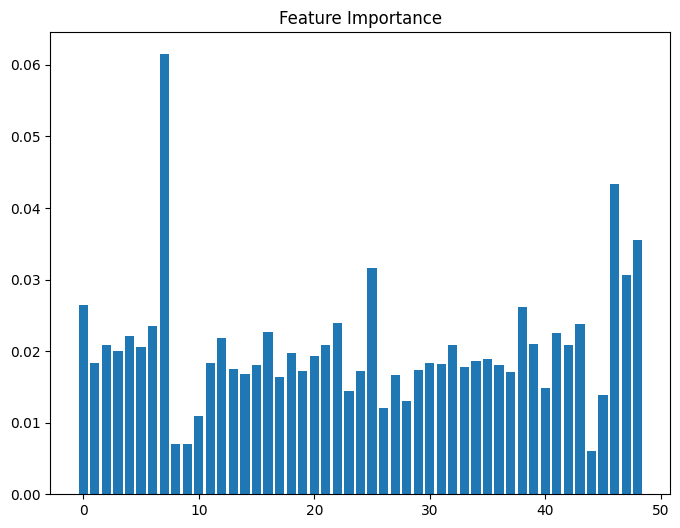

In [35]:
import matplotlib.pyplot as plt

model = pipeline.named_steps["classifier"]
importances = model.feature_importances_

plt.figure(figsize=(8,6))
plt.bar(range(len(importances)), importances)
plt.title("Feature Importance")
plt.show()


### Confusion Matrix Heatmap

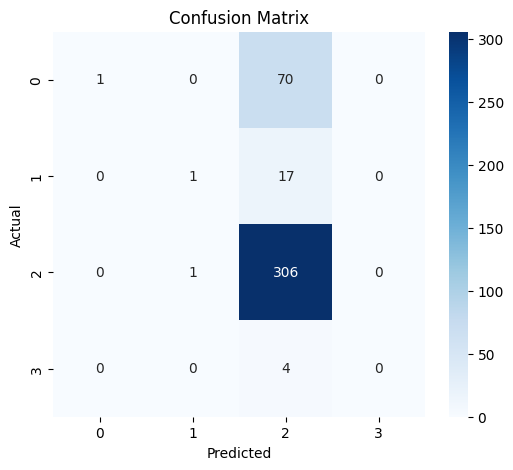

In [36]:
import seaborn as sns

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# ROC Curve

In [37]:
from sklearn.metrics import roc_auc_score

y_proba = pipeline.predict_proba(X_test)

roc_score = roc_auc_score(y_test, y_proba, multi_class='ovr')
print("ROC-AUC Score:", roc_score)


ROC-AUC Score: 0.7798257421322032
